In [67]:
import os
import sys
import clr
import pandas as pd


# ==========================================================
# 1. CONFIGURACIÓN DE LA CONSULTA
#    ESTA ES LA PARTE QUE TÚ MODIFICARÁS
# ==========================================================

TAGS = [
    "FCCPI13162M.PV",
    "FCCFI10561M.DACA.PV",
    "FCCFI30202.DACA.PV",
    "FCCTI30204.DACA.PV",
    "FCCZI10561.PV",
    "FCCZI10461.PV",
    "FCCSI70129B.PV",
    "FCCPDX12601A.DACA.PV",
]


# Rango de tiempo
INICIO = "NOW-6D"
FIN = "NOW"



# Intervalo de muestreo en minutos
INTERVALO_MIN = 30


# Tipo de muestreo:
# "Average"  = promedio de cada intervalo
# "Snapshot" = valor puntual de cada intervalo

TIPO_MUESTREO = "Average"


# ==========================================================
# 2. CONFIGURACIÓN DE UNIFORMANCE PHD
# ==========================================================

RUTA = r"C:\Program Files\Honeywell\Uniformance\Excel Companion"

if RUTA not in sys.path:
    sys.path.append(RUTA)

if hasattr(os, "add_dll_directory"):
    dll_dir = os.add_dll_directory(RUTA)

clr.AddReference(
    os.path.join(RUTA, "phdapinet.dll")
)


# ==========================================================
# 3. IMPORTAR CLASES DE UNIFORMANCE
# ==========================================================

from Uniformance.PHD import (
    PHDServer,
    PHDHistorian,
    Tag,
    SERVERVERSION,
    SAMPLETYPE,
    REDUCTIONTYPE,
    REDUCTIONOFFSET
)


# ==========================================================
# 4. CONECTAR AL SERVIDOR PHD
# ==========================================================

print("Conectando al PHD...")

server = PHDServer(
    "10.2.18.69",
    SERVERVERSION.RAPI200
)

server.ConnectToServer()

print("✅ Conectado al PHD")
print("Servidor:", server.HostName)
print("Puerto:", server.Port)
print("API:", server.APIVersion)


# ==========================================================
# 5. CONFIGURAR CONSULTA HISTÓRICA
# ==========================================================

historian = PHDHistorian()

historian.DefaultServer = server

historian.StartTime = INICIO
historian.EndTime = FIN


# Convertir minutos a segundos
historian.SampleFrequency = INTERVALO_MIN * 60

historian.UseSampleFrequency = True


# ==========================================================
# 6. DEFINIR TIPO DE MUESTREO
# ==========================================================

if TIPO_MUESTREO.lower() == "average":

    historian.Sampletype = SAMPLETYPE.Average

elif TIPO_MUESTREO.lower() == "snapshot":

    historian.Sampletype = SAMPLETYPE.Snapshot

else:

    raise ValueError(
        "TIPO_MUESTREO debe ser 'Average' o 'Snapshot'"
    )


print("\nCONFIGURACIÓN DE CONSULTA")
print("--------------------------")
print("Inicio:", INICIO)
print("Fin:", FIN)
print("Intervalo:", INTERVALO_MIN, "minutos")
print("Tipo:", TIPO_MUESTREO)
print("Número de tags:", len(TAGS))


# ==========================================================
# 7. FUNCIÓN PARA CONSULTAR UN TAG
# ==========================================================

def obtener_tag(nombre_tag):

    print(f"\nConsultando: {nombre_tag}")

    # Crear objeto Tag
    tag = Tag()

    tag.TagName = nombre_tag
    tag.Server = server


    # Sin reducción adicional
    tag.ReductionType = getattr(
        REDUCTIONTYPE,
        "None"
    )

    tag.ReductionFrequency = 0

    tag.ReductionOffset = REDUCTIONOFFSET.Before


    # ======================================================
    # CONSULTAR PHD
    # ======================================================

    datos = historian.FetchDataList(tag)


    # ======================================================
    # CONVERTIR DATOS .NET A PYTHON
    # ======================================================

    timestamps = list(datos.Timestamps)
    valores = list(datos.DataValues)


    # ======================================================
    # CREAR DATAFRAME DEL TAG
    # NO INCLUIMOS CONFIDENCE
    # ======================================================

    df_tag = pd.DataFrame({

        "Timestamp_PHD": timestamps,

        nombre_tag: valores

    })


    # ======================================================
    # CONVERTIR TIMESTAMP PHD A FECHA/HORA
    # ======================================================

    df_tag["FechaHora"] = pd.to_datetime(

        df_tag["Timestamp_PHD"],

        unit="D",

        origin="1899-12-30"

    ).dt.round("min")


    # ======================================================
    # ELIMINAR TIMESTAMP NUMÉRICO
    # ======================================================

    df_tag = df_tag.drop(
        columns=["Timestamp_PHD"]
    )


    # ======================================================
    # SI EXISTE MÁS DE UN DATO EN EL MISMO MINUTO
    # SE QUEDA CON EL PROMEDIO
    # ======================================================

    df_tag = (
        df_tag
        .groupby(
            "FechaHora",
            as_index=False
        )[nombre_tag]
        .mean()
    )


    # ======================================================
    # ORDENAR COLUMNAS
    # ======================================================

    df_tag = df_tag[
        [
            "FechaHora",
            nombre_tag
        ]
    ]


    print(
        f"✅ {len(df_tag)} datos obtenidos"
    )


    return df_tag


# ==========================================================
# 8. CONSULTAR TODOS LOS TAGS
# ==========================================================

dataframes = []


for nombre_tag in TAGS:

    try:

        df_tag = obtener_tag(nombre_tag)

        dataframes.append(df_tag)

    except Exception as e:

        print(
            f"\n❌ Error consultando {nombre_tag}"
        )

        print(e)


# ==========================================================
# 9. VERIFICAR QUE HAYA DATOS
# ==========================================================

if len(dataframes) == 0:

    raise RuntimeError(
        "No se pudo obtener información de ningún tag."
    )


# ==========================================================
# 10. UNIR TODOS LOS TAGS POR FECHA/HORA
# ==========================================================

df = dataframes[0]


for df_tag in dataframes[1:]:

    df = pd.merge(

        df,

        df_tag,

        on="FechaHora",

        how="outer"

    )


# ==========================================================
# 11. ORDENAR RESULTADOS
# ==========================================================

df = df.sort_values(
    "FechaHora"
).reset_index(drop=True)


# ==========================================================
# 12. MOSTRAR RESULTADO FINAL
# ==========================================================

print("\n")
print("=" * 70)
print("✅ CONSULTA PHD TERMINADA")
print("=" * 70)

print("\nCantidad de registros:", len(df))

print("\nDatos:\n")

print(
    df.to_string(
        index=False
    )
)


# ==========================================================
# 13. DATAFRAME FINAL
# ==========================================================

df

Conectando al PHD...
✅ Conectado al PHD
Servidor: 10.2.18.69
Puerto: 3150
API: RAPI200

CONFIGURACIÓN DE CONSULTA
--------------------------
Inicio: NOW-6D
Fin: NOW
Intervalo: 30 minutos
Tipo: Average
Número de tags: 8

Consultando: FCCPI13162M.PV
✅ 289 datos obtenidos

Consultando: FCCFI10561M.DACA.PV
✅ 289 datos obtenidos

Consultando: FCCFI30202.DACA.PV
✅ 289 datos obtenidos

Consultando: FCCTI30204.DACA.PV
✅ 289 datos obtenidos

Consultando: FCCZI10561.PV
✅ 289 datos obtenidos

Consultando: FCCZI10461.PV
✅ 289 datos obtenidos

Consultando: FCCSI70129B.PV
✅ 289 datos obtenidos

Consultando: FCCPDX12601A.DACA.PV
✅ 289 datos obtenidos


✅ CONSULTA PHD TERMINADA

Cantidad de registros: 289

Datos:

          FechaHora  FCCPI13162M.PV  FCCFI10561M.DACA.PV  FCCFI30202.DACA.PV  FCCTI30204.DACA.PV  FCCZI10561.PV  FCCZI10461.PV  FCCSI70129B.PV  FCCPDX12601A.DACA.PV
2026-08-18 16:17:00        0.085092         97989.593750         3846.019043           21.272348      99.498947      42.148613 

,FechaHora,FCCPI13162M.PV,FCCFI10561M.DACA.PV,FCCFI30202.DACA.PV,FCCTI30204.DACA.PV,FCCZI10561.PV,FCCZI10461.PV,FCCSI70129B.PV,FCCPDX12601A.DACA.PV
0,2026-08-18 16:17:00,0.085092,97989.593750,3846.019043,21.272348,99.498947,42.148613,5326.170410,12.647408
1,2026-08-18 16:47:00,0.084575,97969.796875,3848.554199,21.176680,99.531258,42.187344,5326.167969,12.510197
2,2026-08-18 17:17:00,0.085903,97975.898438,3851.604980,21.277897,99.562065,42.201229,5326.757324,12.621731
3,2026-08-18 17:47:00,0.086489,97984.101562,3853.209961,21.127399,99.573639,42.219582,5325.874512,12.533956
4,2026-08-18 18:17:00,0.086832,97958.125000,3855.823486,21.250593,99.598602,42.377560,5326.587402,12.508742
...,...,...,...,...,...,...,...,...,...
284,2026-08-24 14:17:00,0.999452,3507.457520,3.314074,24.391163,99.464386,99.611603,0.000000,99.540009
285,2026-08-24 14:47:00,0.999328,3585.811035,3.327192,24.418165,99.489227,99.591499,0.000000,99.539528
286,2026-08-24 15:17:00,0.998840,3501.518311,3.327664,24.442144,99.547607,99.587997,0.000000,99.542389
287,2026-08-24 15:47:00,0.998878,3371.061768,3.313080,24.454967,99.600624,99.586487,0.000000,99.541466


In [70]:
import os
import sys
import clr
import pandas as pd


# ==========================================================
# 1. CONFIGURACIÓN DE LA CONSULTA
# ==========================================================

# ----------------------------------------------------------
# TAGS DEL PROYECTO
# ----------------------------------------------------------

TAGS = [

    # ======================================================
    # BALANCE DE VAPOR
    # ======================================================

    # Vapor MS importado desde límite de batería
    "FCCFI30303BM.DACA.PV",

    # Vapor MS exportado desde FCC
    "FCCFI30303AM.DACA.PV",

    # Vapor MS generado dentro de FCC
    "FCCFI12901M.DACA.PV",

    # Consumo de vapor turbina del compresor de gases
    "RG1FI00303.DACA.PV",


    # ======================================================
    # CONDENSADOR / VACÍO
    # ======================================================

    # Vacío / presión absoluta del condensador
    "FCCPI13162M.PV",

    # Flujo de agua de mar al condensador
    "FCCFI30202.DACA.PV",

    # Temperatura entrada agua de mar
    "FCCTI30204.DACA.PV",

    # Temperatura salida agua de mar
    "FCCTI30208.DACA.PV",

    # Presión entrada agua de mar
    "FCCPI30204.DACA.PV",


    # ======================================================
    # SOPLADOR / TURBINA
    # ======================================================

    # Flujo de aire del soplador
    "FCCFI10561M.DACA.PV",

    # Temperatura descarga del soplador
    "FCCTI10464.PV",

    # Presión descarga del soplador
    "FCCPI10463.PV",

    # RPM turbina / soplador
    "FCCSI70129B.PV",

    # Presión vapor entrada turbina
    "FCCPI10405M.PV",

    # Temperatura vapor entrada turbina
    "FCCTI10401M.PV",

    # Apertura antisurge
    "FCCZI10461.PV",


    # ======================================================
    # REGENERADOR
    # ======================================================

    # Presión del regenerador
    "FCCPC11203.PIDA.PV",

    # Posición válvula SV3
    "FCCPDX12601B.DACA.PV",


    # ======================================================
    # EYECTORES
    # ======================================================

    # Presión vapor MS hacia eyectores
    "FCCPI30304.DACA.PV",

    # Temperatura vapor MS hacia eyectores
    "FCCTI30304.DACA.PV",
]


# ==========================================================
# 2. RANGO DE TIEMPO
# ==========================================================

# Primera prueba: últimos 7 días
#INICIO = "NOW-7D"
#FIN = "NOW"
INICIO = "2026-08-12 00:00:00"
FIN = "2026-08-18 23:59:00"

# ==========================================================
# 3. INTERVALO
# ==========================================================

# Promedio cada 1 minuto
INTERVALO_MIN = 1


# ==========================================================
# 4. TIPO DE MUESTREO
# ==========================================================

# "Average"  = promedio de los valores dentro del intervalo
# "Snapshot" = valor puntual

TIPO_MUESTREO = "Average"


# ==========================================================
# 5. CONSUMO NOMINAL BOMBA DE FONDOS
# ==========================================================

# kg/h
CONSUMO_BOMBA_FONDOS = 8396


# ==========================================================
# 6. CONFIGURACIÓN DE UNIFORMANCE PHD
# ==========================================================

RUTA = r"C:\Program Files\Honeywell\Uniformance\Excel Companion"

if RUTA not in sys.path:
    sys.path.append(RUTA)

if hasattr(os, "add_dll_directory"):
    dll_dir = os.add_dll_directory(RUTA)

clr.AddReference(
    os.path.join(
        RUTA,
        "phdapinet.dll"
    )
)


# ==========================================================
# 7. IMPORTAR CLASES DE UNIFORMANCE
# ==========================================================

from Uniformance.PHD import (
    PHDServer,
    PHDHistorian,
    Tag,
    SERVERVERSION,
    SAMPLETYPE,
    REDUCTIONTYPE,
    REDUCTIONOFFSET
)


# ==========================================================
# 8. CONECTAR AL SERVIDOR PHD
# ==========================================================

print("Conectando al PHD...")

server = PHDServer(
    "10.2.18.69",
    SERVERVERSION.RAPI200
)

server.ConnectToServer()

print("✅ Conectado al PHD")
print("Servidor:", server.HostName)
print("Puerto:", server.Port)
print("API:", server.APIVersion)


# ==========================================================
# 9. CONFIGURAR CONSULTA HISTÓRICA
# ==========================================================

historian = PHDHistorian()

historian.DefaultServer = server

historian.StartTime = INICIO
historian.EndTime = FIN


# Convertir minutos a segundos
historian.SampleFrequency = INTERVALO_MIN * 60

historian.UseSampleFrequency = True


# ==========================================================
# 10. DEFINIR TIPO DE MUESTREO
# ==========================================================

if TIPO_MUESTREO.lower() == "average":

    historian.Sampletype = SAMPLETYPE.Average

elif TIPO_MUESTREO.lower() == "snapshot":

    historian.Sampletype = SAMPLETYPE.Snapshot

else:

    raise ValueError(
        "TIPO_MUESTREO debe ser 'Average' o 'Snapshot'"
    )


print("\nCONFIGURACIÓN DE CONSULTA")
print("--------------------------")
print("Inicio:", INICIO)
print("Fin:", FIN)
print("Intervalo:", INTERVALO_MIN, "minuto(s)")
print("Tipo:", TIPO_MUESTREO)
print("Número de tags:", len(TAGS))


# ==========================================================
# 11. FUNCIÓN PARA CONSULTAR UN TAG
# ==========================================================

def obtener_tag(nombre_tag):

    print(f"\nConsultando: {nombre_tag}")

    # Crear objeto Tag
    tag = Tag()

    tag.TagName = nombre_tag
    tag.Server = server


    # Sin reducción adicional
    tag.ReductionType = getattr(
        REDUCTIONTYPE,
        "None"
    )

    tag.ReductionFrequency = 0

    tag.ReductionOffset = REDUCTIONOFFSET.Before


    # ======================================================
    # CONSULTAR PHD
    # ======================================================

    datos = historian.FetchDataList(tag)


    # ======================================================
    # CONVERTIR DATOS .NET A PYTHON
    # ======================================================

    timestamps = list(datos.Timestamps)
    valores = list(datos.DataValues)


    # ======================================================
    # CREAR DATAFRAME DEL TAG
    # NO INCLUIMOS CONFIDENCE
    # ======================================================

    df_tag = pd.DataFrame({

        "Timestamp_PHD": timestamps,

        nombre_tag: valores

    })


    # ======================================================
    # CONVERTIR TIMESTAMP PHD A FECHA/HORA
    # ======================================================

    df_tag["FechaHora"] = pd.to_datetime(

        df_tag["Timestamp_PHD"],

        unit="D",

        origin="1899-12-30"

    ).dt.round("min")


    # ======================================================
    # ELIMINAR TIMESTAMP NUMÉRICO
    # ======================================================

    df_tag = df_tag.drop(
        columns=["Timestamp_PHD"]
    )


    # ======================================================
    # SI EXISTE MÁS DE UN DATO EN EL MISMO MINUTO
    # SE QUEDA CON EL PROMEDIO
    # ======================================================

    df_tag = (
        df_tag
        .groupby(
            "FechaHora",
            as_index=False
        )[nombre_tag]
        .mean()
    )


    print(
        f"✅ {len(df_tag)} datos obtenidos"
    )


    return df_tag


# ==========================================================
# 12. CONSULTAR TODOS LOS TAGS
# ==========================================================

dataframes = []


for nombre_tag in TAGS:

    try:

        df_tag = obtener_tag(nombre_tag)

        dataframes.append(df_tag)

    except Exception as e:

        print(
            f"\n❌ Error consultando {nombre_tag}"
        )

        print(e)


# ==========================================================
# 13. VERIFICAR QUE HAYA DATOS
# ==========================================================

if len(dataframes) == 0:

    raise RuntimeError(
        "No se pudo obtener información de ningún tag."
    )


# ==========================================================
# 14. UNIR TODOS LOS TAGS POR FECHA/HORA
# ==========================================================

df = dataframes[0]


for df_tag in dataframes[1:]:

    df = pd.merge(

        df,

        df_tag,

        on="FechaHora",

        how="outer"

    )


# ==========================================================
# 15. ORDENAR RESULTADOS
# ==========================================================

df = df.sort_values(
    "FechaHora"
).reset_index(drop=True)


# ==========================================================
# 16. CAMBIAR NOMBRES DE COLUMNAS
# ==========================================================

df = df.rename(columns={

    # Balance de vapor
    "FCCFI30303BM.DACA.PV":
        "Vapor_MS_Importado_kg_h",

    "FCCFI30303AM.DACA.PV":
        "Vapor_MS_Exportado_kg_h",

    "FCCFI12901M.DACA.PV":
        "Vapor_MS_Generado_kg_h",

    "RG1FI00303.DACA.PV":
        "Vapor_Compresor_Gases_kg_h",


    # Condensador
    "FCCPI13162M.PV":
        "Presion_Condensador_kg_cm2A",

    "FCCFI30202.DACA.PV":
        "Flujo_Agua_Mar_m3_h",

    "FCCTI30204.DACA.PV":
        "Temp_Entrada_Agua_Mar_C",

    "FCCTI30208.DACA.PV":
        "Temp_Salida_Agua_Mar_C",

    "FCCPI30204.DACA.PV":
        "Presion_Entrada_Agua_Mar_kg_cm2",


    # Soplador / turbina
    "FCCFI10561M.DACA.PV":
        "Flujo_Aire_Soplador_kg_h",

    "FCCTI10464.PV":
        "Temp_Descarga_Soplador_C",

    "FCCPI10463.PV":
        "Presion_Descarga_Soplador_kg_cm2",

    "FCCSI70129B.PV":
        "RPM_Turbina",

    "FCCPI10405M.PV":
        "Presion_Vapor_Entrada_Turbina_kg_cm2",

    "FCCTI10401M.PV":
        "Temp_Vapor_Entrada_Turbina_C",

    "FCCZI10461.PV":
        "Apertura_Antisurge_pct",


    # Regenerador
    "FCCPC11203.PIDA.PV":
        "Presion_Regenerador_kg_cm2",

    "FCCPDX12601B.DACA.PV":
        "Apertura_SV3_pct",


    # Eyectores
    "FCCPI30304.DACA.PV":
        "Presion_MS_Eyectores_kg_cm2",

    "FCCTI30304.DACA.PV":
        "Temp_MS_Eyectores_C"

})


# ==========================================================
# 17. CALCULAR CONSUMO DE VAPOR DE LA TURBINA DEL SOPLADOR
# ==========================================================
#
# Balance:
#
# Vapor soplador =
#
#   Vapor importado
# - Vapor exportado
# + Vapor generado
# - Vapor consumido compresor de gases
# - Vapor bomba de fondos
#
# Bomba de fondos:
# 8396 kg/h
#
# ==========================================================

df["Flujo_Vapor_Turbina_kg_h"] = (

    df["Vapor_MS_Importado_kg_h"]

    - df["Vapor_MS_Exportado_kg_h"]

    + df["Vapor_MS_Generado_kg_h"]

    - df["Vapor_Compresor_Gases_kg_h"]

    - CONSUMO_BOMBA_FONDOS

)


# ==========================================================
# 18. CONVERTIR CONSUMO A TONELADAS/HORA
# ==========================================================

df["Flujo_Vapor_Turbina_t_h"] = (

    df["Flujo_Vapor_Turbina_kg_h"] / 1000

)


# ==========================================================
# 19. CREAR VARIABLE ΔT AGUA DE MAR
# ==========================================================

df["DeltaT_Agua_Mar_C"] = (

    df["Temp_Salida_Agua_Mar_C"]

    - df["Temp_Entrada_Agua_Mar_C"]

)


# ==========================================================
# 20. CREAR ESTADO DE OPERACIÓN PRELIMINAR
# ==========================================================
#
# Esto NO elimina datos.
# Solo identifica cuándo la turbina/soplador está detenido.
#
# Después afinaremos este criterio en Databricks.
#
# ==========================================================

df["Estado_Operacion"] = "EN_SERVICIO"

df.loc[
    df["RPM_Turbina"] < 100,
    "Estado_Operacion"
] = "FUERA_DE_SERVICIO"


# ==========================================================
# 21. ORDENAR COLUMNAS
# ==========================================================

columnas_finales = [

    "FechaHora",

    # VARIABLE OBJETIVO
    "Flujo_Vapor_Turbina_t_h",
    "Flujo_Vapor_Turbina_kg_h",

    # VARIABLE PRINCIPAL
    "Presion_Condensador_kg_cm2A",

    # CARGA SOPLADOR
    "Flujo_Aire_Soplador_kg_h",
    "Temp_Descarga_Soplador_C",
    "Presion_Descarga_Soplador_kg_cm2",
    "RPM_Turbina",

    # VAPOR TURBINA
    "Presion_Vapor_Entrada_Turbina_kg_cm2",
    "Temp_Vapor_Entrada_Turbina_C",

    # CONDENSADOR / AGUA DE MAR
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "DeltaT_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",

    # REGENERADOR
    "Presion_Regenerador_kg_cm2",
    "Apertura_SV3_pct",

    # ANTISURGE
    "Apertura_Antisurge_pct",

    # EYECTORES
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",

    # BALANCE DE VAPOR ORIGINAL
    "Vapor_MS_Importado_kg_h",
    "Vapor_MS_Exportado_kg_h",
    "Vapor_MS_Generado_kg_h",
    "Vapor_Compresor_Gases_kg_h",

    # ESTADO
    "Estado_Operacion"
]


df = df[columnas_finales]


# ==========================================================
# 22. MOSTRAR RESULTADO FINAL
# ==========================================================

print("\n")
print("=" * 80)
print("✅ CONSULTA PHD TERMINADA")
print("=" * 80)

print("\nCantidad de registros:", len(df))

print("\nNúmero de variables:", len(df.columns))

print("\nPrimeros registros:\n")

print(
    df.head(20).to_string(
        index=False
    )
)


# ==========================================================
# 23. MOSTRAR RESUMEN DEL CONSUMO CALCULADO
# ==========================================================

print("\n")
print("=" * 80)
print("CONSUMO CALCULADO DE VAPOR - TURBINA SOPLADOR")
print("=" * 80)

print(
    df["Flujo_Vapor_Turbina_t_h"].describe()
)


# ==========================================================
# 24. DATAFRAME FINAL
# ==========================================================

df

Conectando al PHD...
✅ Conectado al PHD
Servidor: 10.2.18.69
Puerto: 3150
API: RAPI200

CONFIGURACIÓN DE CONSULTA
--------------------------
Inicio: 2026-08-12 00:00:00
Fin: 2026-08-18 23:59:00
Intervalo: 1 minuto(s)
Tipo: Average
Número de tags: 20

Consultando: FCCFI30303BM.DACA.PV
✅ 10080 datos obtenidos

Consultando: FCCFI30303AM.DACA.PV
✅ 10080 datos obtenidos

Consultando: FCCFI12901M.DACA.PV
✅ 10080 datos obtenidos

Consultando: RG1FI00303.DACA.PV
✅ 10080 datos obtenidos

Consultando: FCCPI13162M.PV
✅ 10080 datos obtenidos

Consultando: FCCFI30202.DACA.PV
✅ 10080 datos obtenidos

Consultando: FCCTI30204.DACA.PV
✅ 10080 datos obtenidos

Consultando: FCCTI30208.DACA.PV
✅ 10080 datos obtenidos

Consultando: FCCPI30204.DACA.PV
✅ 10080 datos obtenidos

Consultando: FCCFI10561M.DACA.PV
✅ 10080 datos obtenidos

Consultando: FCCTI10464.PV
✅ 10080 datos obtenidos

Consultando: FCCPI10463.PV
✅ 10080 datos obtenidos

Consultando: FCCSI70129B.PV
✅ 10080 datos obtenidos

Consultando: FCCPI10

,FechaHora,Flujo_Vapor_Turbina_t_h,Flujo_Vapor_Turbina_kg_h,Presion_Condensador_kg_cm2A,Flujo_Aire_Soplador_kg_h,Temp_Descarga_Soplador_C,Presion_Descarga_Soplador_kg_cm2,RPM_Turbina,Presion_Vapor_Entrada_Turbina_kg_cm2,Temp_Vapor_Entrada_Turbina_C,...,Presion_Regenerador_kg_cm2,Apertura_SV3_pct,Apertura_Antisurge_pct,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Vapor_MS_Importado_kg_h,Vapor_MS_Exportado_kg_h,Vapor_MS_Generado_kg_h,Vapor_Compresor_Gases_kg_h,Estado_Operacion
0,2026-08-12 00:00:00,29.086434,29086.434032,0.136371,66920.171875,136.474365,1.357143,5323.870605,39.969475,348.920197,...,0.916080,1.211186,57.490845,10.930197,271.903625,37436.476562,0.0,45.957470,0.000000,EN_SERVICIO
1,2026-08-12 00:01:00,28.558436,28558.435703,0.134386,66603.820312,136.143173,1.320513,5326.312500,40.073261,349.492554,...,0.862156,4.538398,57.384003,10.968607,271.885834,36908.929688,0.0,45.506016,0.000000,EN_SERVICIO
2,2026-08-12 00:02:00,28.294126,28294.126255,0.126603,66983.437500,135.758545,1.318987,5330.281250,40.167889,349.969482,...,0.852222,4.705064,57.365692,11.011851,271.865814,36644.234375,0.0,45.891880,0.000000,EN_SERVICIO
3,2026-08-12 00:03:00,27.926092,27926.092064,0.126374,67018.203125,135.523499,1.312271,5330.891602,40.235043,350.408295,...,0.841037,4.961324,57.225277,11.064207,271.836914,36276.105469,0.0,45.986595,0.000000,EN_SERVICIO
4,2026-08-12 00:04:00,27.632948,27632.948494,0.127518,66781.117188,135.149567,1.308913,5329.975586,40.241150,350.713531,...,0.831644,5.002227,56.987179,11.120724,271.831360,35986.828125,0.0,42.120369,0.000000,EN_SERVICIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10075,2026-08-18 23:55:00,33.676523,33676.523438,0.084249,97973.296875,168.557693,2.432235,5324.481445,40.268620,341.517883,...,2.129689,12.346967,42.689255,11.241217,262.886902,31711.203125,0.0,21114.789062,10753.468750,EN_SERVICIO
10076,2026-08-18 23:56:00,33.668102,33668.101562,0.084249,97982.343750,168.547012,2.429487,5329.060059,40.225883,341.327087,...,2.127160,12.924597,42.725883,11.212591,262.879120,31767.919922,0.0,21035.414062,10739.232422,EN_SERVICIO
10077,2026-08-18 23:57:00,33.522654,33522.654297,0.084325,98033.789062,168.557693,2.426435,5324.481445,40.216728,341.422485,...,2.125146,12.390930,42.710625,11.213753,262.901367,31749.892578,0.0,20897.259766,10728.498047,EN_SERVICIO
10078,2026-08-18 23:58:00,33.394415,33394.415039,0.084783,97990.687500,168.611115,2.430403,5323.565430,40.195362,341.517883,...,2.126271,12.957150,42.689255,11.197851,262.933594,31761.769531,0.0,20771.935547,10743.290039,EN_SERVICIO


In [71]:
df.head(5)

,FechaHora,Flujo_Vapor_Turbina_t_h,Flujo_Vapor_Turbina_kg_h,Presion_Condensador_kg_cm2A,Flujo_Aire_Soplador_kg_h,Temp_Descarga_Soplador_C,Presion_Descarga_Soplador_kg_cm2,RPM_Turbina,Presion_Vapor_Entrada_Turbina_kg_cm2,Temp_Vapor_Entrada_Turbina_C,...,Presion_Regenerador_kg_cm2,Apertura_SV3_pct,Apertura_Antisurge_pct,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Vapor_MS_Importado_kg_h,Vapor_MS_Exportado_kg_h,Vapor_MS_Generado_kg_h,Vapor_Compresor_Gases_kg_h,Estado_Operacion
0,2026-08-12 00:00:00,29.086434,29086.434032,0.136371,66920.171875,136.474365,1.357143,5323.870605,39.969475,348.920197,...,0.916080,1.211186,57.490845,10.930197,271.903625,37436.476562,0.0,45.957470,0.0,EN_SERVICIO
1,2026-08-12 00:01:00,28.558436,28558.435703,0.134386,66603.820312,136.143173,1.320513,5326.312500,40.073261,349.492554,...,0.862156,4.538398,57.384003,10.968607,271.885834,36908.929688,0.0,45.506016,0.0,EN_SERVICIO
2,2026-08-12 00:02:00,28.294126,28294.126255,0.126603,66983.437500,135.758545,1.318987,5330.281250,40.167889,349.969482,...,0.852222,4.705064,57.365692,11.011851,271.865814,36644.234375,0.0,45.891880,0.0,EN_SERVICIO
3,2026-08-12 00:03:00,27.926092,27926.092064,0.126374,67018.203125,135.523499,1.312271,5330.891602,40.235043,350.408295,...,0.841037,4.961324,57.225277,11.064207,271.836914,36276.105469,0.0,45.986595,0.0,EN_SERVICIO
4,2026-08-12 00:04:00,27.632948,27632.948494,0.127518,66781.117188,135.149567,1.308913,5329.975586,40.241150,350.713531,...,0.831644,5.002227,56.987179,11.120724,271.831360,35986.828125,0.0,42.120369,0.0,EN_SERVICIO


In [72]:
df.tail(10)

,FechaHora,Flujo_Vapor_Turbina_t_h,Flujo_Vapor_Turbina_kg_h,Presion_Condensador_kg_cm2A,Flujo_Aire_Soplador_kg_h,Temp_Descarga_Soplador_C,Presion_Descarga_Soplador_kg_cm2,RPM_Turbina,Presion_Vapor_Entrada_Turbina_kg_cm2,Temp_Vapor_Entrada_Turbina_C,...,Presion_Regenerador_kg_cm2,Apertura_SV3_pct,Apertura_Antisurge_pct,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Vapor_MS_Importado_kg_h,Vapor_MS_Exportado_kg_h,Vapor_MS_Generado_kg_h,Vapor_Compresor_Gases_kg_h,Estado_Operacion
10070,2026-08-18 23:50:00,33.869944,33869.943912,0.083791,97994.148438,168.867538,2.438645,5324.481445,40.393772,341.346161,...,2.134191,12.447135,42.686203,11.217913,262.663361,31966.955078,2.474057,21067.277344,10765.814453,EN_SERVICIO
10071,2026-08-18 23:51:00,34.064764,34064.764415,0.084173,98172.835938,168.867538,2.432235,5323.565430,40.390720,341.155365,...,2.129481,12.413188,42.686203,11.221031,262.711212,31862.970703,0.412343,21346.390625,10748.184570,EN_SERVICIO
10072,2026-08-18 23:52:00,33.719834,33719.833984,0.084249,98078.984375,168.728638,2.426129,5324.481445,40.387669,341.136292,...,2.124520,12.150805,42.686203,11.219994,262.752319,31569.560547,0.000000,21265.371094,10719.097656,EN_SERVICIO
10073,2026-08-18 23:53:00,33.788087,33788.086914,0.084249,98034.476562,168.643158,2.427961,5329.060059,40.363251,341.269867,...,2.124284,12.138008,42.683151,11.248067,262.811279,31193.154297,0.000000,21715.203125,10724.270508,EN_SERVICIO
10074,2026-08-18 23:54:00,33.693729,33693.728516,0.084249,97968.437500,168.621796,2.433455,5324.481445,40.317459,341.422485,...,2.128216,12.632722,42.667889,11.264947,262.868011,31672.582031,0.000000,21134.521484,10717.375000,EN_SERVICIO
10075,2026-08-18 23:55:00,33.676523,33676.523438,0.084249,97973.296875,168.557693,2.432235,5324.481445,40.268620,341.517883,...,2.129689,12.346967,42.689255,11.241217,262.886902,31711.203125,0.000000,21114.789062,10753.468750,EN_SERVICIO
10076,2026-08-18 23:56:00,33.668102,33668.101562,0.084249,97982.343750,168.547012,2.429487,5329.060059,40.225883,341.327087,...,2.127160,12.924597,42.725883,11.212591,262.879120,31767.919922,0.000000,21035.414062,10739.232422,EN_SERVICIO
10077,2026-08-18 23:57:00,33.522654,33522.654297,0.084325,98033.789062,168.557693,2.426435,5324.481445,40.216728,341.422485,...,2.125146,12.390930,42.710625,11.213753,262.901367,31749.892578,0.000000,20897.259766,10728.498047,EN_SERVICIO
10078,2026-08-18 23:58:00,33.394415,33394.415039,0.084783,97990.687500,168.611115,2.430403,5323.565430,40.195362,341.517883,...,2.126271,12.957150,42.689255,11.197851,262.933594,31761.769531,0.000000,20771.935547,10743.290039,EN_SERVICIO
10079,2026-08-18 23:59:00,33.450783,33450.783203,0.084936,98035.171875,168.579071,2.425824,5323.565430,40.173992,341.327087,...,2.123617,12.308570,42.686203,11.206597,262.952515,31329.181641,0.000000,21293.816406,10776.214844,EN_SERVICIO


In [73]:
df.shape

(10080, 25)

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   FechaHora                             10080 non-null  datetime64[ns]
 1   Flujo_Vapor_Turbina_t_h               10080 non-null  float64       
 2   Flujo_Vapor_Turbina_kg_h              10080 non-null  float64       
 3   Presion_Condensador_kg_cm2A           10080 non-null  float64       
 4   Flujo_Aire_Soplador_kg_h              10080 non-null  float64       
 5   Temp_Descarga_Soplador_C              10080 non-null  float64       
 6   Presion_Descarga_Soplador_kg_cm2      10080 non-null  float64       
 7   RPM_Turbina                           10080 non-null  float64       
 8   Presion_Vapor_Entrada_Turbina_kg_cm2  10080 non-null  float64       
 9   Temp_Vapor_Entrada_Turbina_C          10080 non-null  float64       
 10  Flujo_Agu

In [75]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Presion_Condensador_kg_cm2A"],
        name="Presión condensador",
        yaxis="y1"
    )
)

fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Flujo_Agua_Mar_m3_h"],
        name="Flujo agua de mar",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Presión del condensador vs flujo de agua de mar",

    xaxis=dict(
        title="Fecha y hora"
    ),

    yaxis=dict(
        title="Presión absoluta del condensador (kg/cm²A)"
    ),

    yaxis2=dict(
        title="Flujo de agua de mar (m³/h)",
        overlaying="y",
        side="right"
    ),

    hovermode="x unified"
)

fig.show()

In [76]:
import plotly.graph_objects as go


fig = go.Figure()


# ==========================================================
# 1. PRESIÓN ABSOLUTA DEL CONDENSADOR
# ==========================================================

fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Presion_Condensador_kg_cm2A"],
        name="Presión condensador",
        mode="lines",
        yaxis="y"
    )
)


# ==========================================================
# 2. FLUJO DE AGUA DE MAR
# ==========================================================

fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Flujo_Agua_Mar_m3_h"],
        name="Flujo agua de mar",
        mode="lines",
        yaxis="y2"
    )
)


# ==========================================================
# 3. TEMPERATURA DE ENTRADA DEL AGUA DE MAR
# ==========================================================

fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Temp_Entrada_Agua_Mar_C"],
        name="Temperatura entrada agua de mar",
        mode="lines",
        yaxis="y3"
    )
)


# ==========================================================
# 4. FLUJO DE DESCARGA DEL SOPLADOR
# ==========================================================

fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Flujo_Aire_Soplador_kg_h"],
        name="Flujo descarga soplador",
        mode="lines",
        yaxis="y4"
    )
)


# ==========================================================
# 5. CONFIGURACIÓN DE LA GRÁFICA
# ==========================================================

fig.update_layout(

    title={
        "text": "Comportamiento del condensador, agua de mar y flujo del soplador",
        "x": 0.5,
        "xanchor": "center"
    },


    # EJE X
    xaxis=dict(
        title="Fecha y hora"
    ),


    # ======================================================
    # EJE IZQUIERDO 1
    # PRESIÓN CONDENSADOR
    # ======================================================

    yaxis=dict(
        title="Presión absoluta condensador (kg/cm²A)"
    ),


    # ======================================================
    # EJE DERECHO 1
    # FLUJO AGUA DE MAR
    # ======================================================

    yaxis2=dict(
        title="Flujo agua de mar (m³/h)",
        overlaying="y",
        side="right"
    ),


    # ======================================================
    # EJE DERECHO 2
    # TEMPERATURA AGUA DE MAR
    # ======================================================

    yaxis3=dict(
        title="Temperatura entrada agua de mar (°C)",
        overlaying="y",
        side="right",
        anchor="free",
        position=0.94
    ),


    # ======================================================
    # EJE IZQUIERDO 2
    # FLUJO SOPLADOR
    # ======================================================

    yaxis4=dict(
        title="Flujo descarga soplador (kg/h)",
        overlaying="y",
        side="left",
        anchor="free",
        position=0.06
    ),


    # Mostrar todos los valores al pasar el cursor
    hovermode="x unified",


    # Leyenda arriba
    legend=dict(
        orientation="h",
        x=0.5,
        xanchor="center",
        y=1.12
    ),


    # Espacio extra para los ejes
    margin=dict(
        l=170,
        r=220,
        t=130,
        b=80
    )
)


fig.show()

In [77]:
import plotly.graph_objects as go

fig = go.Figure()


# 1. PRESIÓN ABSOLUTA DEL CONDENSADOR
fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Presion_Condensador_kg_cm2A"],
        name="Presión condensador",
        mode="lines",
        yaxis="y"
    )
)


# 2. FLUJO DE AGUA DE MAR
fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Flujo_Agua_Mar_m3_h"],
        name="Flujo agua de mar",
        mode="lines",
        yaxis="y2"
    )
)


# 3. TEMPERATURA DE ENTRADA DEL AGUA DE MAR
fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Temp_Entrada_Agua_Mar_C"],
        name="Temperatura entrada agua de mar",
        mode="lines",
        yaxis="y3"
    )
)


# 4. FLUJO DE DESCARGA DEL SOPLADOR
fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Flujo_Aire_Soplador_kg_h"],
        name="Flujo descarga soplador",
        mode="lines",
        yaxis="y4"
    )
)


# 5. FLUJO DE VAPOR DE LA TURBINA
fig.add_trace(
    go.Scatter(
        x=df["FechaHora"],
        y=df["Flujo_Vapor_Turbina_t_h"],
        name="Flujo vapor turbina",
        mode="lines",
        yaxis="y5"
    )
)


# CONFIGURACIÓN
fig.update_layout(

    title={
        "text": "Comportamiento del condensador, agua de mar, soplador y consumo de vapor",
        "x": 0.5,
        "xanchor": "center"
    },

    xaxis=dict(
        title="Fecha y hora"
    ),

    # Ejes Y ocultos
    yaxis=dict(
        title=None,
        showticklabels=False,
        showgrid=False
    ),

    yaxis2=dict(
        title=None,
        overlaying="y",
        side="right",
        showticklabels=False,
        showgrid=False
    ),

    yaxis3=dict(
        title=None,
        overlaying="y",
        side="right",
        anchor="free",
        position=0.94,
        showticklabels=False,
        showgrid=False
    ),

    yaxis4=dict(
        title=None,
        overlaying="y",
        side="left",
        anchor="free",
        position=0.05,
        showticklabels=False,
        showgrid=False
    ),

    yaxis5=dict(
        title=None,
        overlaying="y",
        side="left",
        anchor="free",
        position=0.10,
        showticklabels=False,
        showgrid=False
    ),

    hovermode="x unified",

    legend=dict(
        orientation="h",
        x=0.5,
        xanchor="center",
        y=1.13
    ),

    margin=dict(
        l=50,
        r=50,
        t=130,
        b=80
    )
)

fig.show()

In [78]:
print("Filas:", len(df))
print("Columnas:", len(df.columns))

print("\nValores nulos:")
print(df.isnull().sum())

print("\nResumen estadístico:")
print(df.describe())

Filas: 10080
Columnas: 25

Valores nulos:
FechaHora                               0
Flujo_Vapor_Turbina_t_h                 0
Flujo_Vapor_Turbina_kg_h                0
Presion_Condensador_kg_cm2A             0
Flujo_Aire_Soplador_kg_h                0
Temp_Descarga_Soplador_C                0
Presion_Descarga_Soplador_kg_cm2        0
RPM_Turbina                             0
Presion_Vapor_Entrada_Turbina_kg_cm2    0
Temp_Vapor_Entrada_Turbina_C            0
Flujo_Agua_Mar_m3_h                     0
Temp_Entrada_Agua_Mar_C                 0
Temp_Salida_Agua_Mar_C                  0
DeltaT_Agua_Mar_C                       0
Presion_Entrada_Agua_Mar_kg_cm2         0
Presion_Regenerador_kg_cm2              0
Apertura_SV3_pct                        0
Apertura_Antisurge_pct                  0
Presion_MS_Eyectores_kg_cm2             0
Temp_MS_Eyectores_C                     0
Vapor_MS_Importado_kg_h                 0
Vapor_MS_Exportado_kg_h                 0
Vapor_MS_Generado_kg_h            

In [79]:
# Resumen estadístico de todas las variables
df.describe().T

,count,mean,min,25%,50%,75%,max,std
FechaHora,10080,2026-08-15 11:59:30,2026-08-12 00:00:00,2026-08-13 17:59:45,2026-08-15 11:59:30,2026-08-17 05:59:15,2026-08-18 23:59:00,NaN
Flujo_Vapor_Turbina_t_h,10080.0,33.124597,24.752832,32.962407,33.666409,34.199767,36.634325,2.173883
Flujo_Vapor_Turbina_kg_h,10080.0,33124.597465,24752.832485,32962.406738,33666.40918,34199.766846,36634.325261,2173.882625
Presion_Condensador_kg_cm2A,10080.0,0.095202,0.047085,0.079976,0.088446,0.111722,0.142018,0.020766
Flujo_Aire_Soplador_kg_h,10080.0,99488.718934,66603.820312,98010.148438,99968.398438,102229.955078,107466.609375,6041.018212
Temp_Descarga_Soplador_C,10080.0,164.829081,132.222229,164.273514,167.692307,169.32692,178.440186,9.790118
Presion_Descarga_Soplador_kg_cm2,10080.0,2.273416,1.173382,2.269231,2.411172,2.437424,2.496948,0.306771
RPM_Turbina,10080.0,5326.377588,5313.950195,5324.175781,5325.396973,5328.754883,5340.659668,3.046579
Presion_Vapor_Entrada_Turbina_kg_cm2,10080.0,40.641301,37.380955,40.177048,40.711235,41.26984,42.625153,0.701975
Temp_Vapor_Entrada_Turbina_C,10080.0,337.227986,328.353943,333.31427,337.110825,339.972534,365.937897,5.491715


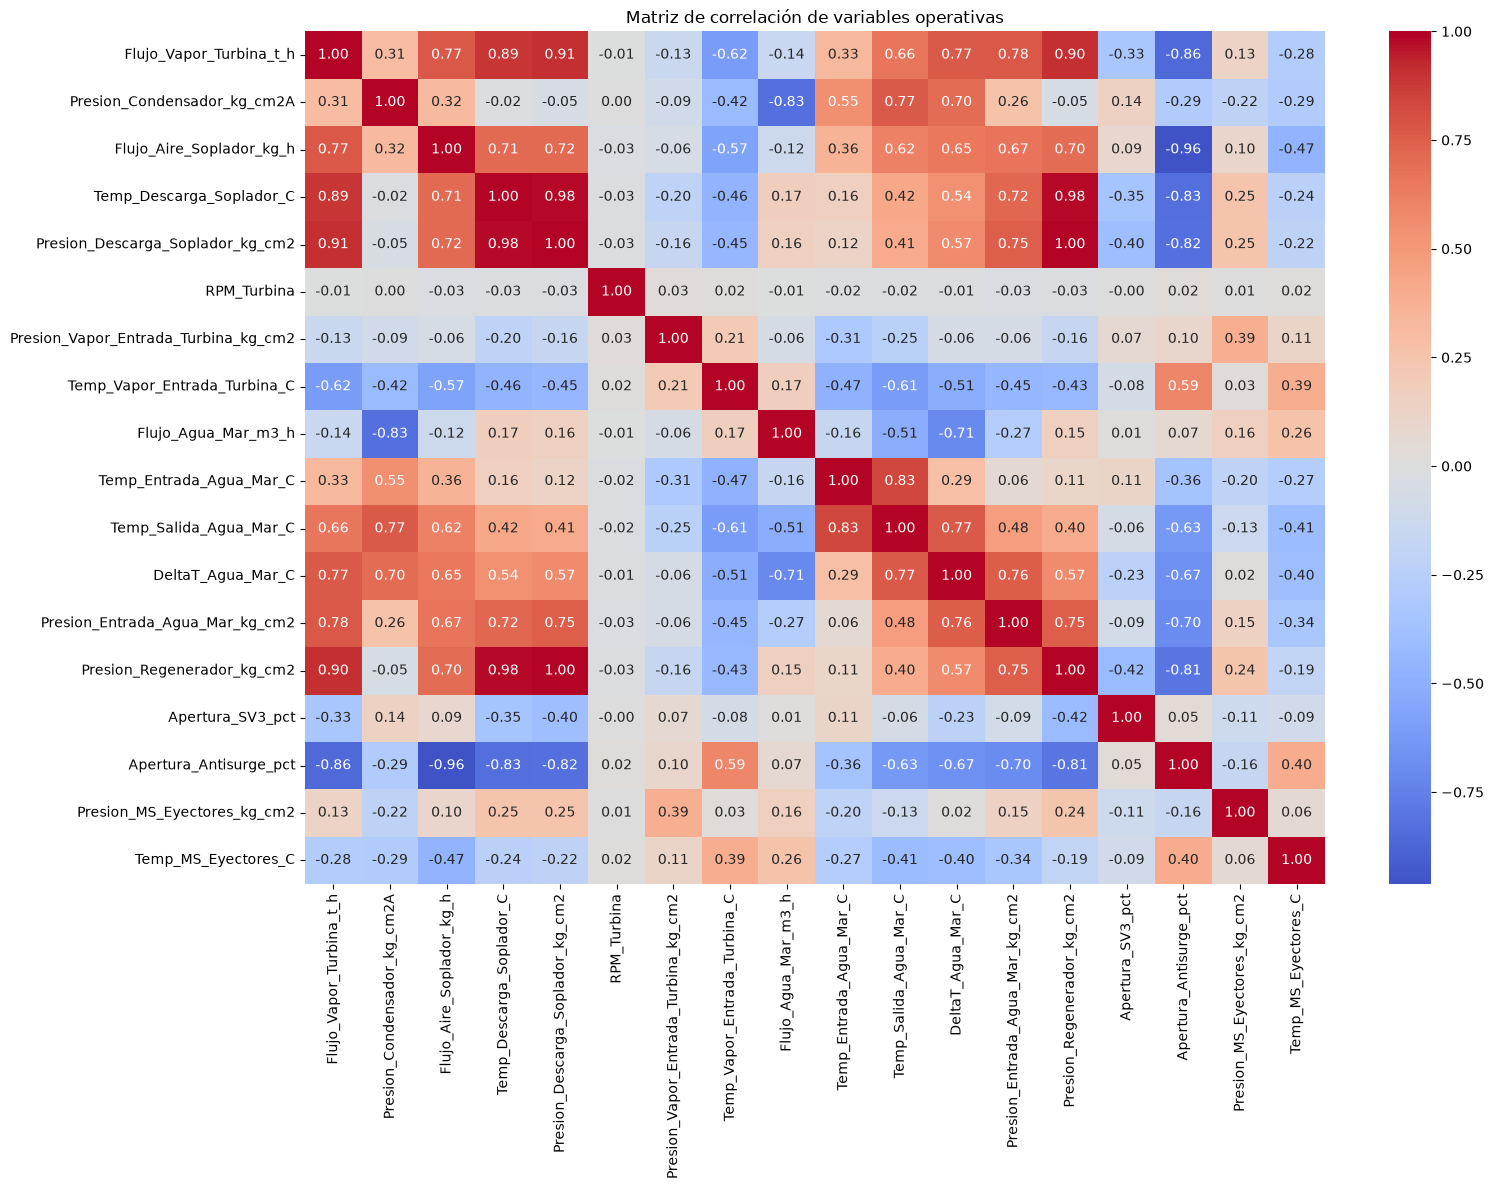

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    "Flujo_Vapor_Turbina_t_h",
    "Presion_Condensador_kg_cm2A",
    "Flujo_Aire_Soplador_kg_h",
    "Temp_Descarga_Soplador_C",
    "Presion_Descarga_Soplador_kg_cm2",
    "RPM_Turbina",
    "Presion_Vapor_Entrada_Turbina_kg_cm2",
    "Temp_Vapor_Entrada_Turbina_C",
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "DeltaT_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",
    "Presion_Regenerador_kg_cm2",
    "Apertura_SV3_pct",
    "Apertura_Antisurge_pct",
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C"
]

correlacion = df[variables].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables operativas")
plt.tight_layout()
plt.show()

In [81]:
df_carga_similar = df[
    (df["Flujo_Aire_Soplador_kg_h"] >= 98000) &
    (df["Flujo_Aire_Soplador_kg_h"] <= 102000)
].copy()

print("Registros encontrados:", len(df_carga_similar))

Registros encontrados: 4480


In [82]:
correlacion_controlada = df_carga_similar[
    [
        "Presion_Condensador_kg_cm2A",
        "Flujo_Vapor_Turbina_t_h"
    ]
].corr()

print(correlacion_controlada)

                             Presion_Condensador_kg_cm2A  \
Presion_Condensador_kg_cm2A                      1.00000   
Flujo_Vapor_Turbina_t_h                          0.21434   

                             Flujo_Vapor_Turbina_t_h  
Presion_Condensador_kg_cm2A                  0.21434  
Flujo_Vapor_Turbina_t_h                      1.00000  


In [83]:
import plotly.express as px

fig = px.scatter(
    df_carga_similar,
    x="Presion_Condensador_kg_cm2A",
    y="Flujo_Vapor_Turbina_t_h",
    trendline="ols",
    title="Vacío vs consumo de vapor a carga similar del soplador",
    labels={
        "Presion_Condensador_kg_cm2A":
            "Presión absoluta del condensador (kg/cm²A)",
        "Flujo_Vapor_Turbina_t_h":
            "Consumo de vapor de la turbina (t/h)"
    }
)

fig.show()

In [84]:
df_carga_controlada = df[
    (df["Flujo_Aire_Soplador_kg_h"] >= 98000) &
    (df["Flujo_Aire_Soplador_kg_h"] <= 102000) &
    (df["Presion_Descarga_Soplador_kg_cm2"] >= 2.35) &
    (df["Presion_Descarga_Soplador_kg_cm2"] <= 2.45)
].copy()

print("Número de registros:", len(df_carga_controlada))

Número de registros: 2421


In [85]:
correlacion_controlada = df_carga_controlada[
    [
        "Presion_Condensador_kg_cm2A",
        "Flujo_Vapor_Turbina_t_h"
    ]
].corr()

print(correlacion_controlada)

                             Presion_Condensador_kg_cm2A  \
Presion_Condensador_kg_cm2A                     1.000000   
Flujo_Vapor_Turbina_t_h                         0.610083   

                             Flujo_Vapor_Turbina_t_h  
Presion_Condensador_kg_cm2A                 0.610083  
Flujo_Vapor_Turbina_t_h                     1.000000  


In [86]:
import plotly.express as px

fig = px.scatter(
    df_carga_controlada,
    x="Presion_Condensador_kg_cm2A",
    y="Flujo_Vapor_Turbina_t_h",
    trendline="ols",
    title="Vacío vs consumo de vapor a condiciones similares de carga",
    labels={
        "Presion_Condensador_kg_cm2A":
            "Presión absoluta del condensador (kg/cm²A)",
        "Flujo_Vapor_Turbina_t_h":
            "Consumo de vapor de la turbina (t/h)"
    }
)

fig.show()

In [87]:
resultados = px.get_trendline_results(fig)

modelo = resultados.iloc[0]["px_fit_results"]

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     1434.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):          7.73e-247
Time:                        16:16:43   Log-Likelihood:                -701.25
No. Observations:                2421   AIC:                             1407.
Df Residuals:                    2419   BIC:                             1418.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.1241      0.067    463.044      0.0

In [88]:
pendiente = modelo.params[1]
intercepto = modelo.params[0]
r2 = modelo.rsquared

print("Intercepto:", intercepto)
print("Pendiente:", pendiente)
print("R²:", r2)

Intercepto: 31.124115569061257
Pendiente: 31.842074901023533
R²: 0.3722011158280869


In [89]:
import statsmodels.api as sm


# ==========================================================
# VARIABLES DEL MODELO
# ==========================================================

X = df[
    [
        "Presion_Condensador_kg_cm2A",
        "Flujo_Aire_Soplador_kg_h",
        "Presion_Descarga_Soplador_kg_cm2",
        "Presion_Vapor_Entrada_Turbina_kg_cm2",
        "Temp_Vapor_Entrada_Turbina_C"
    ]
]

# Variable objetivo
y = df["Flujo_Vapor_Turbina_t_h"]


# ==========================================================
# AGREGAR CONSTANTE
# ==========================================================

X = sm.add_constant(X)


# ==========================================================
# CREAR MODELO
# ==========================================================

modelo_multiple = sm.OLS(y, X).fit()


# ==========================================================
# RESULTADOS
# ==========================================================

print(modelo_multiple.summary())

                               OLS Regression Results                              
Dep. Variable:     Flujo_Vapor_Turbina_t_h   R-squared:                       0.957
Model:                                 OLS   Adj. R-squared:                  0.957
Method:                      Least Squares   F-statistic:                 4.472e+04
Date:                     Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                             16:16:43   Log-Likelihood:                -6284.1
No. Observations:                    10080   AIC:                         1.258e+04
Df Residuals:                        10074   BIC:                         1.262e+04
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

In [90]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd


# Variables predictoras
X_vif = df[
    [
        "Presion_Condensador_kg_cm2A",
        "Flujo_Aire_Soplador_kg_h",
        "Presion_Descarga_Soplador_kg_cm2",
        "Presion_Vapor_Entrada_Turbina_kg_cm2",
        "Temp_Vapor_Entrada_Turbina_C"
    ]
].copy()


# Calcular VIF
vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]


# Ordenar de mayor a menor
vif = vif.sort_values(
    by="VIF",
    ascending=False
)

print(vif)

                               Variable          VIF
3  Presion_Vapor_Entrada_Turbina_kg_cm2  2964.881827
4          Temp_Vapor_Entrada_Turbina_C  2380.565485
1              Flujo_Aire_Soplador_kg_h   761.503257
2      Presion_Descarga_Soplador_kg_cm2   144.350795
0           Presion_Condensador_kg_cm2A    30.676591


In [91]:
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor


# ==========================================================
# VARIABLES PREDICTORAS
# ==========================================================

X_vif = df[
    [
        "Presion_Condensador_kg_cm2A",
        "Flujo_Aire_Soplador_kg_h",
        "Presion_Descarga_Soplador_kg_cm2",
        "Presion_Vapor_Entrada_Turbina_kg_cm2",
        "Temp_Vapor_Entrada_Turbina_C"
    ]
].copy()


# ==========================================================
# AGREGAR CONSTANTE
# ==========================================================

X_vif = sm.add_constant(X_vif)


# ==========================================================
# CALCULAR VIF
# ==========================================================

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]


# ==========================================================
# ELIMINAR LA CONSTANTE DEL RESULTADO
# ==========================================================

vif = vif[
    vif["Variable"] != "const"
]


# ==========================================================
# ORDENAR
# ==========================================================

vif = vif.sort_values(
    by="VIF",
    ascending=False
)

print(vif)

                               Variable       VIF
2              Flujo_Aire_Soplador_kg_h  2.974713
3      Presion_Descarga_Soplador_kg_cm2  2.694192
5          Temp_Vapor_Entrada_Turbina_C  1.768417
1           Presion_Condensador_kg_cm2A  1.567728
4  Presion_Vapor_Entrada_Turbina_kg_cm2  1.090625


In [92]:
df_modelo = df.sort_values("FechaHora").copy()

In [93]:
variables_X = [
    "Presion_Condensador_kg_cm2A",
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2",
    "Presion_Vapor_Entrada_Turbina_kg_cm2",
    "Temp_Vapor_Entrada_Turbina_C"
]

X = df_modelo[variables_X]

y = df_modelo["Flujo_Vapor_Turbina_t_h"]

In [94]:
corte = int(len(df_modelo) * 0.80)

X_train = X.iloc[:corte]
X_test = X.iloc[corte:]

y_train = y.iloc[:corte]
y_test = y.iloc[corte:]

print("Datos entrenamiento:", len(X_train))
print("Datos prueba:", len(X_test))

print("\nPeriodo entrenamiento:")
print(df_modelo["FechaHora"].iloc[0], "→", df_modelo["FechaHora"].iloc[corte - 1])

print("\nPeriodo prueba:")
print(df_modelo["FechaHora"].iloc[corte], "→", df_modelo["FechaHora"].iloc[-1])

Datos entrenamiento: 8064
Datos prueba: 2016

Periodo entrenamiento:
2026-08-12 00:00:00 → 2026-08-17 14:23:00

Periodo prueba:
2026-08-17 14:24:00 → 2026-08-18 23:59:00


In [95]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[34.82,-0. , 6.4 , 0.18,-0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Presion_Condensador_kg_cm2A','Flujo_Aire_Soplador_kg_h', 'Presion_Descarga_Soplador_kg_cm2','Presion_Vapor_Entrada_Turbina_kg_cm2', 'Temp_Vapor_Entrada_Turbina_C']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,23.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [96]:
y_pred = modelo_lr.predict(X_test)

In [97]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.22924534532169155
RMSE: 0.2943278267523385
R²: 0.5623305946072341


In [98]:
import plotly.graph_objects as go

fechas_test = df_modelo["FechaHora"].iloc[corte:]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=fechas_test,
        y=y_test,
        mode="lines",
        name="Consumo real"
    )
)

fig.add_trace(
    go.Scatter(
        x=fechas_test,
        y=y_pred,
        mode="lines",
        name="Consumo predicho"
    )
)

fig.update_layout(
    title="Consumo real vs consumo predicho de vapor de la turbina",
    xaxis_title="Fecha y hora",
    yaxis_title="Consumo de vapor (t/h)",
    hovermode="x unified"
)

fig.show()

In [99]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(
    X_train,
    y_train
)

y_pred_rf = modelo_rf.predict(X_test)

In [100]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest")
print("----------------")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest
----------------
MAE: 0.24281589383333838
RMSE: 0.3049626456577143
R²: 0.530130954787223


In [101]:
from sklearn.ensemble import GradientBoostingRegressor

modelo_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

modelo_gb.fit(X_train, y_train)

y_pred_gb = modelo_gb.predict(X_test)

In [103]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("-----------------")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

Gradient Boosting
-----------------
MAE: 0.23813321477412433
RMSE: 0.3031203850703929
R²: 0.5357907078959989


In [104]:
# ==========================================================
# MODELO 1
# PREDICCIÓN DE LA PRESIÓN DEL CONDENSADOR
# ==========================================================


# Ordenar los datos cronológicamente
df_modelo_vacio = df.sort_values("FechaHora").copy()


# ==========================================================
# VARIABLES PREDICTORAS
# ==========================================================

variables_vacio = [

    # SISTEMA DE AGUA DE MAR
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",

    # EYECTORES
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",

    # CARGA DEL SOPLADOR
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2",

    # CONDICIONES DE LA TURBINA
    "Presion_Vapor_Entrada_Turbina_kg_cm2",
    "Temp_Vapor_Entrada_Turbina_C"
]


# Variables X
X_vacio = df_modelo_vacio[variables_vacio]


# Variable objetivo Y
y_vacio = df_modelo_vacio[
    "Presion_Condensador_kg_cm2A"
]


print("Número de registros:", len(df_modelo_vacio))
print("Número de variables predictoras:", len(variables_vacio))

Número de registros: 10080
Número de variables predictoras: 9


In [105]:
# ==========================================================
# DIVISIÓN TEMPORAL
# 80 % ENTRENAMIENTO
# 20 % PRUEBA
# ==========================================================

corte_vacio = int(
    len(df_modelo_vacio) * 0.80
)


X_train_vacio = X_vacio.iloc[:corte_vacio]
X_test_vacio = X_vacio.iloc[corte_vacio:]


y_train_vacio = y_vacio.iloc[:corte_vacio]
y_test_vacio = y_vacio.iloc[corte_vacio:]


print(
    "Datos entrenamiento:",
    len(X_train_vacio)
)

print(
    "Datos prueba:",
    len(X_test_vacio)
)


print("\nPeriodo entrenamiento:")

print(
    df_modelo_vacio["FechaHora"].iloc[0],
    "→",
    df_modelo_vacio["FechaHora"].iloc[corte_vacio - 1]
)


print("\nPeriodo prueba:")

print(
    df_modelo_vacio["FechaHora"].iloc[corte_vacio],
    "→",
    df_modelo_vacio["FechaHora"].iloc[-1]
)

Datos entrenamiento: 8064
Datos prueba: 2016

Periodo entrenamiento:
2026-08-12 00:00:00 → 2026-08-17 14:23:00

Periodo prueba:
2026-08-17 14:24:00 → 2026-08-18 23:59:00


In [106]:
from sklearn.linear_model import LinearRegression


# ==========================================================
# REGRESIÓN LINEAL
# ==========================================================

modelo_vacio_lr = LinearRegression()


modelo_vacio_lr.fit(
    X_train_vacio,
    y_train_vacio
)


# Predicción
y_pred_vacio_lr = modelo_vacio_lr.predict(
    X_test_vacio
)

In [107]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


# ==========================================================
# MÉTRICAS REGRESIÓN LINEAL
# ==========================================================

mae_vacio_lr = mean_absolute_error(
    y_test_vacio,
    y_pred_vacio_lr
)


rmse_vacio_lr = np.sqrt(
    mean_squared_error(
        y_test_vacio,
        y_pred_vacio_lr
    )
)


r2_vacio_lr = r2_score(
    y_test_vacio,
    y_pred_vacio_lr
)


print("REGRESIÓN LINEAL - MODELO VACÍO")
print("--------------------------------")

print("MAE:", mae_vacio_lr)
print("RMSE:", rmse_vacio_lr)
print("R²:", r2_vacio_lr)

REGRESIÓN LINEAL - MODELO VACÍO
--------------------------------
MAE: 0.004611404983104034
RMSE: 0.005048614625940987
R²: -0.4966973145366549


In [108]:
import plotly.graph_objects as go


fechas_test_vacio = (
    df_modelo_vacio["FechaHora"]
    .iloc[corte_vacio:]
)


fig = go.Figure()


# VACÍO REAL
fig.add_trace(
    go.Scatter(
        x=fechas_test_vacio,
        y=y_test_vacio,
        mode="lines",
        name="Presión real"
    )
)


# VACÍO PREDICHO
fig.add_trace(
    go.Scatter(
        x=fechas_test_vacio,
        y=y_pred_vacio_lr,
        mode="lines",
        name="Presión predicha"
    )
)


fig.update_layout(

    title="Presión real vs presión predicha del condensador",

    xaxis_title="Fecha y hora",

    yaxis_title=(
        "Presión absoluta del condensador "
        "(kg/cm²A)"
    ),

    hovermode="x unified"
)


fig.show()

In [109]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# ==========================================================
# RANDOM FOREST - MODELO DE VACÍO
# ==========================================================

modelo_vacio_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


# Entrenar modelo
modelo_vacio_rf.fit(
    X_train_vacio,
    y_train_vacio
)


# Realizar predicciones
y_pred_vacio_rf = modelo_vacio_rf.predict(
    X_test_vacio
)


# ==========================================================
# EVALUACIÓN
# ==========================================================

mae_vacio_rf = mean_absolute_error(
    y_test_vacio,
    y_pred_vacio_rf
)

rmse_vacio_rf = np.sqrt(
    mean_squared_error(
        y_test_vacio,
        y_pred_vacio_rf
    )
)

r2_vacio_rf = r2_score(
    y_test_vacio,
    y_pred_vacio_rf
)


print("RANDOM FOREST - MODELO VACÍO")
print("--------------------------------")

print("MAE:", mae_vacio_rf)
print("RMSE:", rmse_vacio_rf)
print("R²:", r2_vacio_rf)

RANDOM FOREST - MODELO VACÍO
--------------------------------
MAE: 0.004456808544477621
RMSE: 0.005430726860406558
R²: -0.731830795405271


In [114]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ==========================================================
# RANDOM FOREST - DIVISIÓN ALEATORIA
# ==========================================================

modelo_vacio_rf_r = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
modelo_vacio_rf_r.fit(
    X_train_vacio_r,
    y_train_vacio_r
)

# Predicción
y_pred_vacio_rf_r = modelo_vacio_rf_r.predict(
    X_test_vacio_r
)

# ==========================================================
# MÉTRICAS
# ==========================================================

mae_vacio_rf_r = mean_absolute_error(
    y_test_vacio_r,
    y_pred_vacio_rf_r
)

rmse_vacio_rf_r = np.sqrt(
    mean_squared_error(
        y_test_vacio_r,
        y_pred_vacio_rf_r
    )
)

r2_vacio_rf_r = r2_score(
    y_test_vacio_r,
    y_pred_vacio_rf_r
)

print("RANDOM FOREST - PRUEBA ALEATORIA")
print("--------------------------------")

print("MAE:", mae_vacio_rf_r)
print("RMSE:", rmse_vacio_rf_r)
print("R²:", r2_vacio_rf_r)

RANDOM FOREST - PRUEBA ALEATORIA
--------------------------------
MAE: 0.0014438489515814397
RMSE: 0.0023436580897786617
R²: 0.9867075950726075


In [115]:
import pandas as pd

importancias_vacio = pd.DataFrame({
    "Variable": variables_vacio,
    "Importancia": modelo_vacio_rf_r.feature_importances_
})

importancias_vacio = (
    importancias_vacio
    .sort_values(
        by="Importancia",
        ascending=False
    )
    .reset_index(drop=True)
)

print(importancias_vacio)

                               Variable  Importancia
0                   Flujo_Agua_Mar_m3_h     0.824622
1               Temp_Entrada_Agua_Mar_C     0.128681
2              Flujo_Aire_Soplador_kg_h     0.010465
3                   Temp_MS_Eyectores_C     0.008667
4      Presion_Descarga_Soplador_kg_cm2     0.008084
5           Presion_MS_Eyectores_kg_cm2     0.007927
6          Temp_Vapor_Entrada_Turbina_C     0.006872
7       Presion_Entrada_Agua_Mar_kg_cm2     0.002584
8  Presion_Vapor_Entrada_Turbina_kg_cm2     0.002098


In [116]:
import plotly.express as px

fig = px.scatter(
    df_modelo_vacio,
    x="Flujo_Agua_Mar_m3_h",
    y="Presion_Condensador_kg_cm2A",

    title="Flujo de agua de mar vs presión del condensador",

    labels={
        "Flujo_Agua_Mar_m3_h":
            "Flujo de agua de mar (m³/h)",

        "Presion_Condensador_kg_cm2A":
            "Presión absoluta del condensador (kg/cm²A)"
    }
)

fig.show()

In [117]:
fig = px.scatter(
    df_modelo_vacio,
    x="Temp_Entrada_Agua_Mar_C",
    y="Presion_Condensador_kg_cm2A",

    title="Temperatura de entrada del agua de mar vs presión del condensador",

    labels={
        "Temp_Entrada_Agua_Mar_C":
            "Temperatura entrada agua de mar (°C)",

        "Presion_Condensador_kg_cm2A":
            "Presión absoluta del condensador (kg/cm²A)"
    }
)

fig.show()